# Notebook 04 — Model Training & Evaluation

**Purpose:** Train the Random Forest classifier and Naïve Bayes baseline, evaluate both models, and generate all performance figures for Chapter 4.

**Steps:**
1. Load preprocessed dataset
2. TF-IDF vectorisation (fit on training set only)
3. Stratified 80/20 train/test split
4. SMOTE balancing on training set only
5. Train Random Forest (n=100 trees, 5-fold CV)
6. Train Naïve Bayes baseline
7. Evaluate: accuracy, precision, recall, F1, confusion matrix
8. Save model.pkl and vectoriser.pkl

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

sys.path.append(os.path.abspath('..'))

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size':   12,
    'figure.dpi':  150,
})

FIGURES_DIR = '../outputs/figures/'
REPORTS_DIR = '../outputs/reports/'
MODELS_DIR  = '../models/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load preprocessed dataset ─────────────────────────────────────────────────
df = pd.read_csv('../data/processed/preprocessed_dataset.csv')
print(f'Dataset loaded: {len(df)} messages')
print(f'Label distribution:')
print(df['label_str'].value_counts())
df.head(3)

Dataset loaded: 3886 messages
Label distribution:
label_str
HAM     2422
SPAM    1464
Name: count, dtype: int64


,label,label_str,message,cleaned_message
0,1,SPAM,CANCLE,cancle
1,1,SPAM,Your plan Smallie.is going to be renewed. Plea...,your plan smallie going renewed please send ca...
2,1,SPAM,"Dear Glo subscriber, you just passed 80% of yo...",dear glo subscriber you passed 80 your plan va...


In [3]:
# ── TF-IDF Vectorisation ──────────────────────────────────────────────────────
# Stratified 80/20 split FIRST, then fit vectoriser on training set only

X_raw = df['cleaned_message']
y     = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {len(X_train_raw)}')
print(f'Test size  : {len(X_test_raw)}')
print(f'Train class distribution: {dict(y_train.value_counts())}')
print(f'Test  class distribution: {dict(y_test.value_counts())}')

Train size : 3108
Test size  : 778
Train class distribution: {0: np.int64(1937), 1: np.int64(1171)}
Test  class distribution: {0: np.int64(485), 1: np.int64(293)}


In [4]:
# Fit vectoriser on training set only — transform both sets
vectoriser = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = vectoriser.fit_transform(X_train_raw)
X_test_tfidf  = vectoriser.transform(X_test_raw)

print(f'Training feature matrix : {X_train_tfidf.shape}')
print(f'Testing  feature matrix : {X_test_tfidf.shape}')

Training feature matrix : (3108, 5000)
Testing  feature matrix : (778, 5000)


In [5]:
# ── SMOTE Balancing ───────────────────────────────────────────────────────────
# Applied to training set ONLY

print('Class distribution BEFORE SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_tfidf, y_train)

print('\nClass distribution AFTER SMOTE:')
unique, counts = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c}')
print(f'\nBalanced training size: {X_train_bal.shape[0]}')

Class distribution BEFORE SMOTE:
  Class 0: 1937
  Class 1: 1171

Class distribution AFTER SMOTE:
  Class 0: 1937
  Class 1: 1937

Balanced training size: 3874


In [6]:
# ── Train Random Forest ───────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation on balanced training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    rf, X_train_bal, y_train_bal,
    cv=cv, scoring='f1', n_jobs=-1
)

print('Random Forest — 5-Fold Cross-Validation F1 Scores:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  Mean CV F1 : {cv_scores.mean():.4f}')
print(f'  Std  CV F1 : {cv_scores.std():.4f}')

# Final fit on full balanced training set
rf.fit(X_train_bal, y_train_bal)
print('\nRandom Forest training complete.')

Random Forest — 5-Fold Cross-Validation F1 Scores:
  Fold 1: 0.8895
  Fold 2: 0.8981
  Fold 3: 0.8855
  Fold 4: 0.9005
  Fold 5: 0.9010
  Mean CV F1 : 0.8949
  Std  CV F1 : 0.0063

Random Forest training complete.


In [7]:
# ── Train Naïve Bayes Baseline ────────────────────────────────────────────────
nb = BernoulliNB()
nb.fit(X_train_bal, y_train_bal)
print('Naïve Bayes (Baseline) training complete.')

Naïve Bayes (Baseline) training complete.


In [8]:
# ── Evaluate Both Models ──────────────────────────────────────────────────────
rf_pred = rf.predict(X_test_tfidf)
nb_pred = nb.predict(X_test_tfidf)

def evaluate(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    print(f'\n{"-"*50}')
    print(f'  Model     : {name}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f} ({prec*100:.2f}%)')
    print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
    print(f'  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
    print(f'  Confusion Matrix:')
    print(f'    TN={cm[0,0]}  FP={cm[0,1]}')
    print(f'    FN={cm[1,0]}  TP={cm[1,1]}')
    print()
    print(classification_report(y_true, y_pred, target_names=['HAM','SPAM']))
    return {'model': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'cm': cm}

rf_metrics = evaluate('Random Forest', y_test, rf_pred)
nb_metrics = evaluate('Naïve Bayes (Baseline)', y_test, nb_pred)


--------------------------------------------------
  Model     : Random Forest
  Accuracy  : 0.8740  (87.40%)
  Precision : 0.8374 (83.74%)
  Recall    : 0.8259  (82.59%)
  F1-Score  : 0.8316  (83.16%)
  Confusion Matrix:
    TN=438  FP=47
    FN=51  TP=242

              precision    recall  f1-score   support

         HAM       0.90      0.90      0.90       485
        SPAM       0.84      0.83      0.83       293

    accuracy                           0.87       778
   macro avg       0.87      0.86      0.87       778
weighted avg       0.87      0.87      0.87       778


--------------------------------------------------
  Model     : Naïve Bayes (Baseline)
  Accuracy  : 0.8599  (85.99%)
  Precision : 0.8485 (84.85%)
  Recall    : 0.7645  (76.45%)
  F1-Score  : 0.8043  (80.43%)
  Confusion Matrix:
    TN=445  FP=40
    FN=69  TP=224

              precision    recall  f1-score   support

         HAM       0.87      0.92      0.89       485
        SPAM       0.85      0.76  

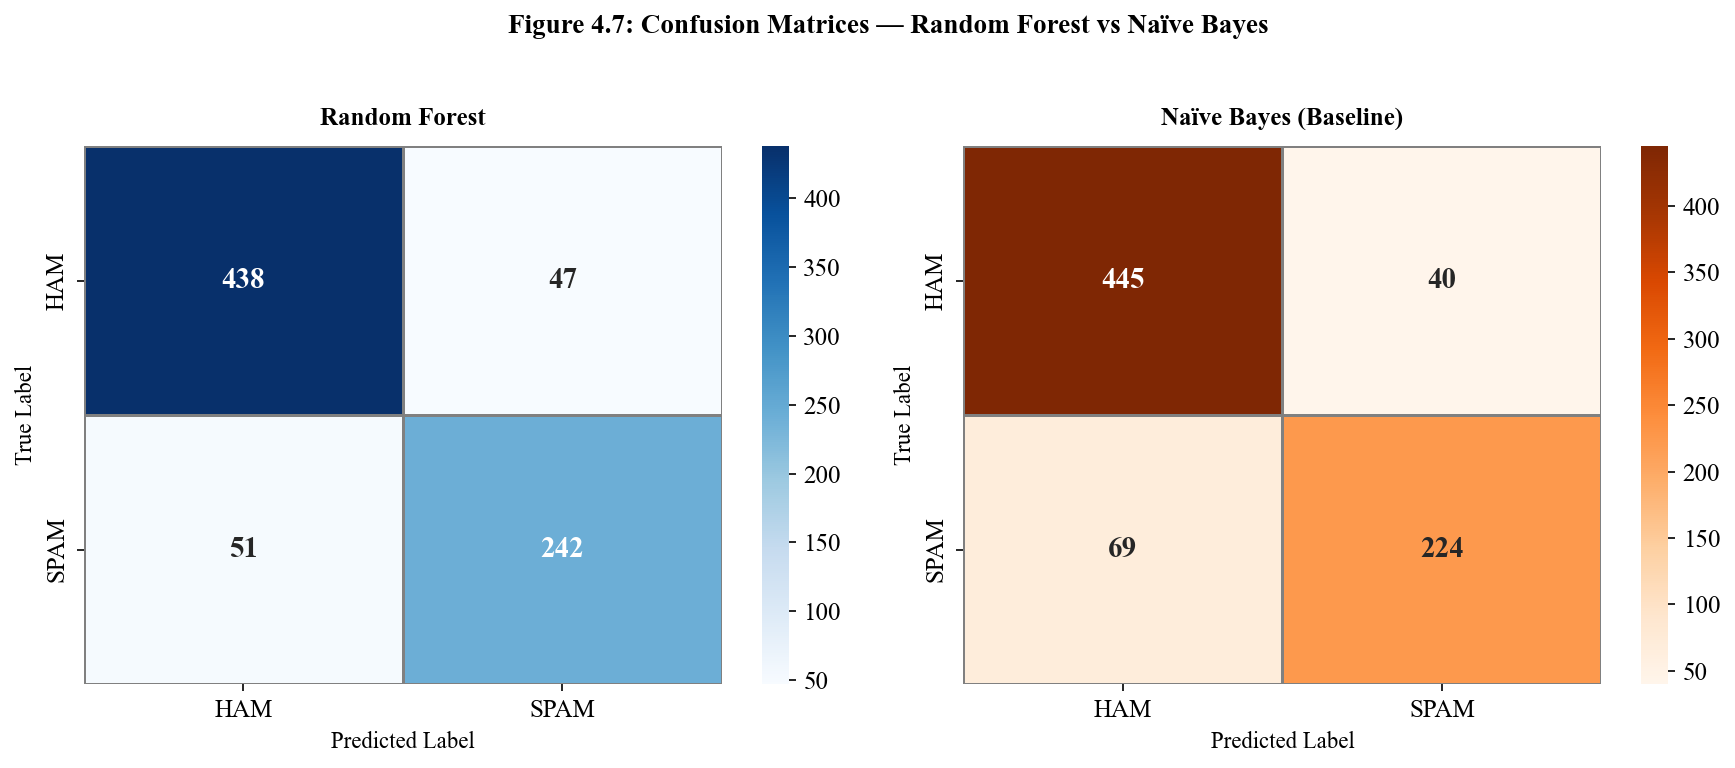

Saved: fig4_7_confusion_matrices.png


In [9]:
# ── Fig 4.7: Confusion Matrix — Random Forest ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, m, title, cmap in [
    (axes[0], rf_metrics, 'Random Forest', 'Blues'),
    (axes[1], nb_metrics, 'Naïve Bayes (Baseline)', 'Oranges'),
]:
    sns.heatmap(
        m['cm'], annot=True, fmt='d',
        cmap=cmap,
        xticklabels=['HAM','SPAM'],
        yticklabels=['HAM','SPAM'],
        ax=ax,
        linewidths=0.5,
        linecolor='gray',
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

fig.suptitle('Figure 4.7: Confusion Matrices — Random Forest vs Naïve Bayes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_7_confusion_matrices.png')

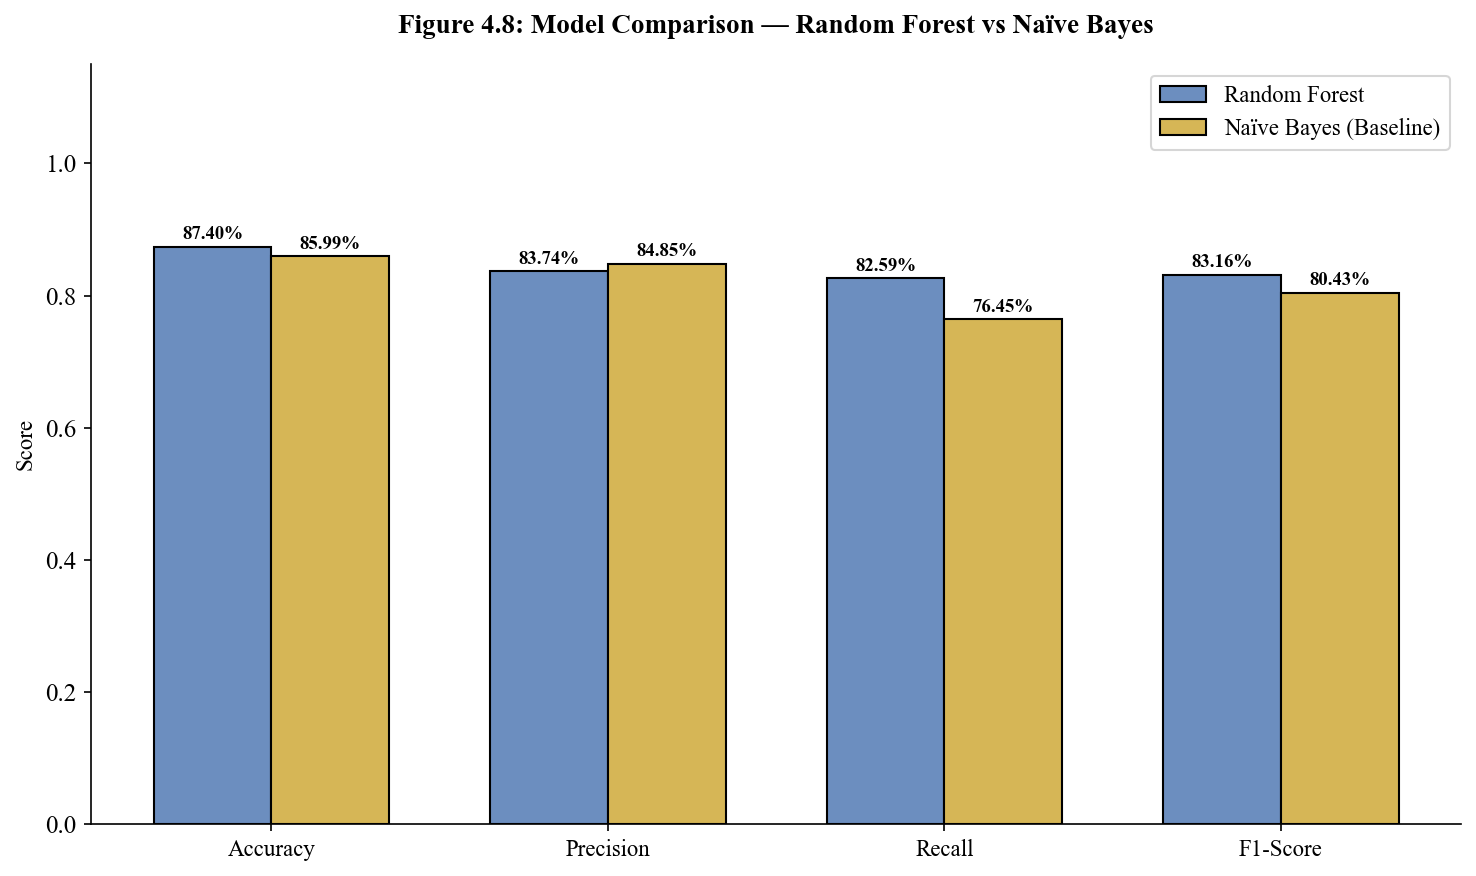

Saved: fig4_8_model_comparison.png


In [10]:
# ── Fig 4.8: Model Comparison Bar Chart ──────────────────────────────────────
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_vals = [rf_metrics['accuracy'], rf_metrics['precision'],
           rf_metrics['recall'],   rf_metrics['f1']]
nb_vals = [nb_metrics['accuracy'], nb_metrics['precision'],
           nb_metrics['recall'],   nb_metrics['f1']]

x     = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rf_vals, width,
               label='Random Forest', color='#6c8ebf', edgecolor='black')
bars2 = ax.bar(x + width/2, nb_vals, width,
               label='Naïve Bayes (Baseline)', color='#d6b656', edgecolor='black')

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height()*100:.2f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

ax.set_title('Figure 4.8: Model Comparison — Random Forest vs Naïve Bayes',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_8_model_comparison.png')

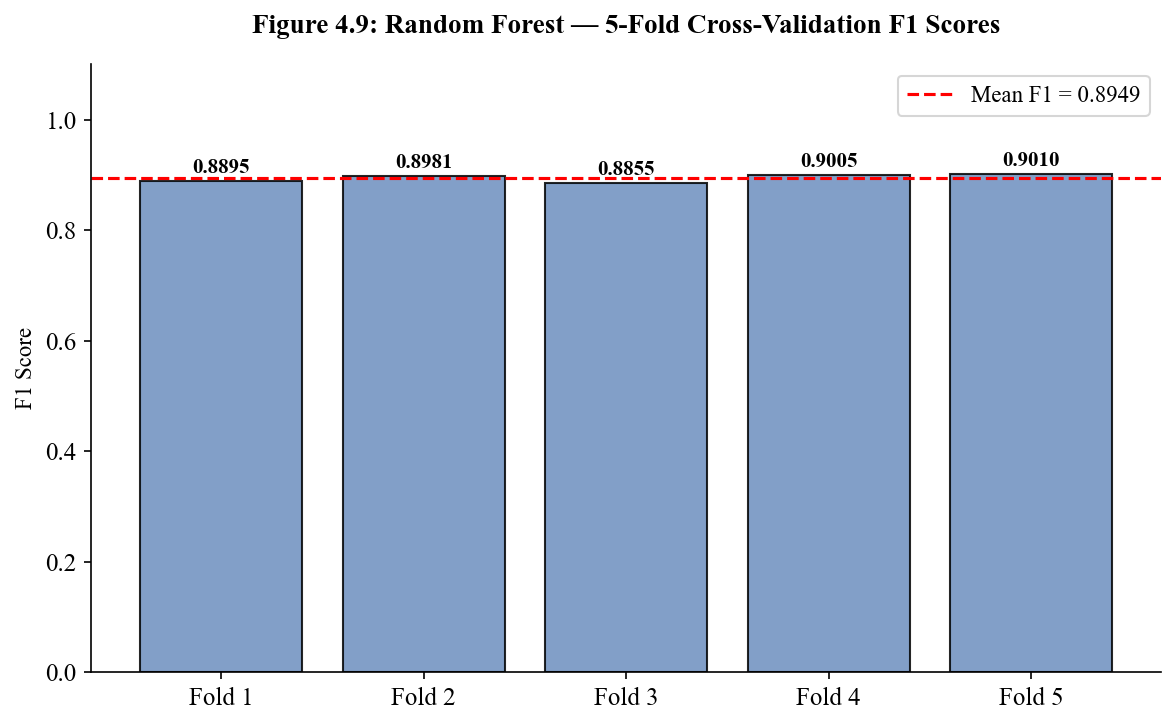

Saved: fig4_9_cv_scores.png


In [11]:
# ── Fig 4.9: Cross-Validation F1 Scores ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

folds = [f'Fold {i}' for i in range(1, 6)]
bars  = ax.bar(folds, cv_scores, color='#6c8ebf', edgecolor='black', alpha=0.85)

for bar, score in zip(bars, cv_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{score:.4f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.axhline(y=cv_scores.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean F1 = {cv_scores.mean():.4f}')
ax.set_title('Figure 4.9: Random Forest — 5-Fold Cross-Validation F1 Scores',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_9_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_9_cv_scores.png')

In [12]:
# ── Save metrics to CSV report ────────────────────────────────────────────────
results_df = pd.DataFrame([
    {
        'Model':     'Random Forest',
        'Accuracy':  round(rf_metrics['accuracy'],  4),
        'Precision': round(rf_metrics['precision'], 4),
        'Recall':    round(rf_metrics['recall'],    4),
        'F1-Score':  round(rf_metrics['f1'],        4),
        'TN': rf_metrics['cm'][0,0],
        'FP': rf_metrics['cm'][0,1],
        'FN': rf_metrics['cm'][1,0],
        'TP': rf_metrics['cm'][1,1],
    },
    {
        'Model':     'Naïve Bayes (Baseline)',
        'Accuracy':  round(nb_metrics['accuracy'],  4),
        'Precision': round(nb_metrics['precision'], 4),
        'Recall':    round(nb_metrics['recall'],    4),
        'F1-Score':  round(nb_metrics['f1'],        4),
        'TN': nb_metrics['cm'][0,0],
        'FP': nb_metrics['cm'][0,1],
        'FN': nb_metrics['cm'][1,0],
        'TP': nb_metrics['cm'][1,1],
    }
])

report_path = os.path.join(REPORTS_DIR, 'model_metrics.csv')
results_df.to_csv(report_path, index=False)
print('Model Metrics Summary:')
print(results_df.to_string(index=False))
print(f'\nSaved: {report_path}')

Model Metrics Summary:
                 Model  Accuracy  Precision  Recall  F1-Score  TN  FP  FN  TP
         Random Forest    0.8740     0.8374  0.8259    0.8316 438  47  51 242
Naïve Bayes (Baseline)    0.8599     0.8485  0.7645    0.8043 445  40  69 224

Saved: ../outputs/reports/model_metrics.csv


In [13]:
# ── Serialise model and vectoriser ────────────────────────────────────────────
joblib.dump(rf,         os.path.join(MODELS_DIR, 'model.pkl'))
joblib.dump(vectoriser, os.path.join(MODELS_DIR, 'vectoriser.pkl'))

print('Serialised artefacts saved:')
print(f'  {MODELS_DIR}model.pkl')
print(f'  {MODELS_DIR}vectoriser.pkl')
print()
print('=' * 50)
print('TRAINING & EVALUATION COMPLETE')
print('=' * 50)
print(f'  Random Forest  — Accuracy: {rf_metrics["accuracy"]*100:.2f}%  F1: {rf_metrics["f1"]*100:.2f}%')
print(f'  Naïve Bayes    — Accuracy: {nb_metrics["accuracy"]*100:.2f}%  F1: {nb_metrics["f1"]*100:.2f}%')

Serialised artefacts saved:
  ../models/model.pkl
  ../models/vectoriser.pkl

TRAINING & EVALUATION COMPLETE
  Random Forest  — Accuracy: 87.40%  F1: 83.16%
  Naïve Bayes    — Accuracy: 85.99%  F1: 80.43%
